# SIT720 HD Task 11.1 
## Option 3: Heart Disease Classification
### Reproducing Bhagat, Sharma & Agarwal (2025), then testing how trustworthy its evaluation is


* **Part 1** reconstructs the paper's six classifiers and stacking ensemble, following the settings
  the paper documents and stating my assumptions where it doesn't.
* **Diagnostics** check how duplicated records affect the reconstruction.
* **Part 2** is my proposed protocol: deduplicate, keep all preprocessing inside the training folds,
  and use nested cross-validation. I then test directly whether it gives a more accurate estimate of
  performance on unseen records than the paper's protocol does.


In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import json, platform, importlib.metadata as ilm
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import (train_test_split, StratifiedKFold, GroupKFold,
                                     GridSearchCV, GroupShuffleSplit)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

RNG = 42
np.random.seed(RNG)

C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "savefig.bbox": "tight", "savefig.dpi": 150})
RESULTS = {}

## 1. Load and audit the dataset
The file has 13 predictors plus `target` (the paper's "14 attributes" include the target).

In [2]:
df = pd.read_csv("heart_1025.csv")
FEATURES = [c for c in df.columns if c != "target"]
u = df.drop_duplicates()
RESULTS["data"] = dict(
    rows=len(df), distinct=int(len(u)), duplicates=int(df.duplicated().sum()),
    pos=int((df.target == 1).sum()), neg=int((df.target == 0).sum()),
    distinct_pos=int((u.target == 1).sum()), distinct_neg=int((u.target == 0).sum()),
    missing=int(df.isna().sum().sum()),
    ca_eq4_rows=int((df.ca == 4).sum()), thal_eq0_rows=int((df.thal == 0).sum()),
    ca_eq4_distinct=int((u.ca == 4).sum()), thal_eq0_distinct=int((u.thal == 0).sum()),
    conflicting_profiles=int(df.groupby(FEATURES)["target"].nunique().gt(1).sum()))
print(RESULTS["data"])
df.head()

{'rows': 1025, 'distinct': 302, 'duplicates': 723, 'pos': 526, 'neg': 499, 'distinct_pos': 164, 'distinct_neg': 138, 'missing': 0, 'ca_eq4_rows': 18, 'thal_eq0_rows': 7, 'ca_eq4_distinct': 4, 'thal_eq0_distinct': 2, 'conflicting_profiles': 0}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 1.1 Where do the 302 distinct records come from?
The paper says it merged four databases (Cleveland, Hungary, Switzerland, Long Beach VA). A merge of
those four would have roughly 920 records with a lot of missing values. Here I compare the 302
distinct records with the widely used 303-row Cleveland-only version of the same Kaggle-style file
(`cleveland_303_reference.csv`, see README for its source).

In [3]:
ref = pd.read_csv("cleveland_303_reference.csv", encoding="utf-8-sig")
ref.columns = [c.strip() for c in ref.columns]
refu = ref.drop_duplicates()
m = u.merge(refu, how="outer", indicator=True)
RESULTS["provenance"] = dict(
    ref_rows=len(ref), ref_distinct=int(len(refu)),
    matched=int((m["_merge"] == "both").sum()),
    only_in_1025=int((m["_merge"] == "left_only").sum()),
    only_in_reference=int((m["_merge"] == "right_only").sum()))
print(RESULTS["provenance"])
print(f"Distinct records with ca=4: {RESULTS['data']['ca_eq4_distinct']}, with thal=0: {RESULTS['data']['thal_eq0_distinct']}")
print("(UCI documents 4 missing 'ca' and 2 missing 'thal' values in the Cleveland data.)")

{'ref_rows': 303, 'ref_distinct': 302, 'matched': 302, 'only_in_1025': 0, 'only_in_reference': 0}
Distinct records with ca=4: 4, with thal=0: 2
(UCI documents 4 missing 'ca' and 2 missing 'thal' values in the Cleveland data.)


## 2. Shared helpers
Base learners follow the settings the paper documents: the decision tree splits on **entropy**
(paper Table 3, Eq. 2) and KNN uses Euclidean distance (Table 7). The paper's Naive Bayes builds
frequency tables (Table 6), which isn't defined for continuous features like age or cholesterol
without a binning scheme the paper doesn't give, so I use Gaussian Naive Bayes as the closest
standard equivalent. Everything else the paper leaves unspecified uses library defaults.

In [4]:
def specificity(yt, yp):
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

def evaluate(yt, yp, pr):
    return dict(Accuracy=accuracy_score(yt, yp), Precision=precision_score(yt, yp, zero_division=0),
                Recall=recall_score(yt, yp), F1=f1_score(yt, yp), Specificity=specificity(yt, yp),
                MCC=matthews_corrcoef(yt, yp), AUC=roc_auc_score(yt, pr))

def base_models():
    return [("LR",  LogisticRegression(max_iter=1000, random_state=RNG)),
            ("DT",  DecisionTreeClassifier(criterion="entropy", random_state=RNG)),
            ("RF",  RandomForestClassifier(n_estimators=100, random_state=RNG)),
            ("XGB", XGBClassifier(n_estimators=100, eval_metric="logloss", verbosity=0, random_state=RNG)),
            ("NB",  GaussianNB()),
            ("KNN", KNeighborsClassifier(n_neighbors=5, metric="euclidean"))]

def pipe(est):
    return Pipeline([("scaler", StandardScaler()), ("clf", est)])

def paper_stack(estimators, cv):
    return StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=1000),
                              cv=cv, stack_method="predict_proba")

SINGLES = ["LR", "DT", "RF", "XGB", "NB", "KNN"]

# PART 1 : Reconstructing the paper
The paper isn't consistent about preprocessing order: the abstract, Section 3 and Fig. 1 preprocess
before splitting, while the step-by-step algorithm (Table 8) splits first. I follow Table 8 and fit the
scaler on the training split only, then check below that the other order makes almost no difference.
The split is 80/20, inferred from the paper's 205-case confusion matrix. The paper doesn't say whether it
stratified; I stratify with seed 42, which gives 100 negative / 105 positive test cases against the
paper's 95/110.

In [5]:
X = df[FEATURES].values
y = df["target"].values
Xtr_raw, Xte_raw, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=RNG, stratify=y)
scaler = StandardScaler().fit(Xtr_raw)      
Xtr, Xte = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)
RESULTS["part1_split"] = dict(train=len(ytr), test=len(yte),
                              test_neg=int((yte == 0).sum()), test_pos=int((yte == 1).sum()))

PART1 = SINGLES + ["Stack"]
p1, cm1 = {}, {}
for name, model in base_models():
    model.fit(Xtr, ytr)
    yp, pr = model.predict(Xte), model.predict_proba(Xte)[:, 1]
    p1[name], cm1[name] = evaluate(yte, yp, pr), confusion_matrix(yte, yp)
stack = paper_stack(base_models(), cv=5).fit(Xtr, ytr)
yp, pr = stack.predict(Xte), stack.predict_proba(Xte)[:, 1]
p1["Stack"], cm1["Stack"] = evaluate(yte, yp, pr), confusion_matrix(yte, yp)
RESULTS["part1"] = p1
RESULTS["part1_cm"] = {k: v.tolist() for k, v in cm1.items()}
print(RESULTS["part1_split"])
pd.DataFrame(p1).T.round(4)

{'train': 820, 'test': 205, 'test_neg': 100, 'test_pos': 105}


,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC
LR,0.8098,0.7619,0.9143,0.8312,0.70,0.6309,0.9298
DT,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
RF,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
XGB,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
NB,0.8293,0.8070,0.8762,0.8402,0.78,0.6602,0.9043
KNN,0.8634,0.8738,0.8571,0.8654,0.87,0.7269,0.9629
Stack,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000


In [6]:

scaler_all = StandardScaler().fit(X)
Xtr_a, Xte_a = scaler_all.transform(Xtr_raw), scaler_all.transform(Xte_raw)
alt = {}
for name, model in base_models():
    model.fit(Xtr_a, ytr)
    alt[name] = evaluate(yte, model.predict(Xte_a), model.predict_proba(Xte_a)[:, 1])
st_a = paper_stack(base_models(), cv=5).fit(Xtr_a, ytr)
alt["Stack"] = evaluate(yte, st_a.predict(Xte_a), st_a.predict_proba(Xte_a)[:, 1])
RESULTS["order_sensitivity"] = dict(
    max_abs_acc_diff_pp=round(100 * max(abs(alt[k]["Accuracy"] - p1[k]["Accuracy"]) for k in PART1), 2),
    max_abs_auc_diff=round(max(abs(alt[k]["AUC"] - p1[k]["AUC"]) for k in PART1), 4))
print("Split-then-scale vs scale-then-split:", RESULTS["order_sensitivity"])

Split-then-scale vs scale-then-split: {'max_abs_acc_diff_pp': 0.0, 'max_abs_auc_diff': 0.0003}


In [7]:
PAPER = {
    "LR":    dict(Accuracy=0.8439, F1=0.8620, Recall=0.9090, Precision=0.8196, AUC=0.9204),
    "NB":    dict(Accuracy=0.8439, F1=0.8608, Recall=0.9000, Precision=0.8250, AUC=0.9185),
    "KNN":   dict(Accuracy=0.8585, F1=0.8687, Recall=0.8727, Precision=0.8648, AUC=0.9304),
    "DT":    dict(Accuracy=0.9268, F1=0.9289, Recall=0.8909, Precision=0.9702, AUC=0.9702),
    "RF":    dict(Accuracy=0.9268, F1=0.9333, Recall=0.9545, Precision=0.9130, AUC=0.9734),
    "XGB":   dict(Accuracy=0.9073, F1=0.9132, Recall=0.9090, Precision=0.9174, AUC=0.9830),
    "Stack": dict(Accuracy=0.9853, F1=0.9861, Recall=0.9727, Precision=1.0000, AUC=0.9880)}
RESULTS["paper_table11"] = PAPER
METRICS5 = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

RESULTS["paper_vs_reconstruction"] = {k: {m: dict(paper=PAPER[k][m], ours=p1[k][m],
                                                  diff_pp=100 * (p1[k][m] - PAPER[k][m]))
                                          for m in METRICS5} for k in PART1}
side_by_side = pd.DataFrame({f"{m} {src}": [PAPER[k][m] if src == "paper" else round(p1[k][m], 4) for k in PART1]
                             for m in METRICS5 for src in ["paper", "ours"]}, index=PART1)
display(side_by_side)
print("Reconstruction minus paper, percentage points:")
pd.DataFrame({m: [round(100 * (p1[k][m] - PAPER[k][m]), 2) for k in PART1] for m in METRICS5}, index=PART1)

,Accuracy paper,Accuracy ours,Precision paper,Precision ours,Recall paper,Recall ours,F1 paper,F1 ours,AUC paper,AUC ours
LR,0.8439,0.8098,0.8196,0.7619,0.9090,0.9143,0.8620,0.8312,0.9204,0.9298
DT,0.9268,1.0000,0.9702,1.0000,0.8909,1.0000,0.9289,1.0000,0.9702,1.0000
RF,0.9268,1.0000,0.9130,1.0000,0.9545,1.0000,0.9333,1.0000,0.9734,1.0000
XGB,0.9073,1.0000,0.9174,1.0000,0.9090,1.0000,0.9132,1.0000,0.9830,1.0000
NB,0.8439,0.8293,0.8250,0.8070,0.9000,0.8762,0.8608,0.8402,0.9185,0.9043
KNN,0.8585,0.8634,0.8648,0.8738,0.8727,0.8571,0.8687,0.8654,0.9304,0.9629
Stack,0.9853,1.0000,1.0000,1.0000,0.9727,1.0000,0.9861,1.0000,0.9880,1.0000


Reconstruction minus paper, percentage points:


,Accuracy,Precision,Recall,F1,AUC
LR,-3.41,-5.77,0.53,-3.08,0.94
DT,7.32,2.98,10.91,7.11,2.98
RF,7.32,8.70,4.55,6.67,2.66
XGB,9.27,8.26,9.10,8.68,1.70
NB,-1.46,-1.80,-2.38,-2.06,-1.42
KNN,0.49,0.90,-1.56,-0.33,3.25
Stack,1.47,0.00,2.73,1.39,1.20


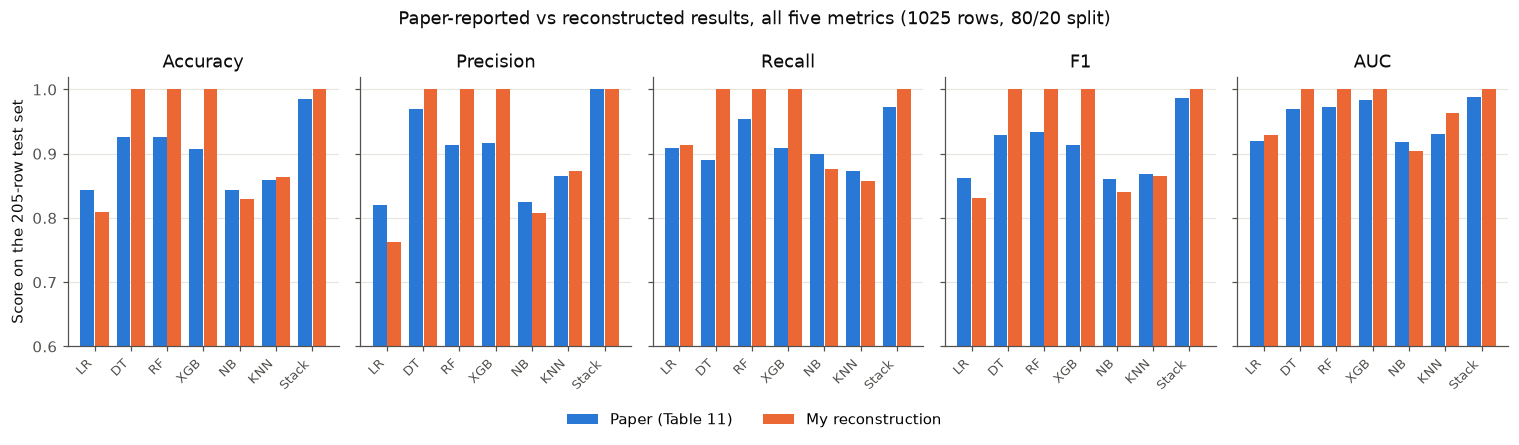

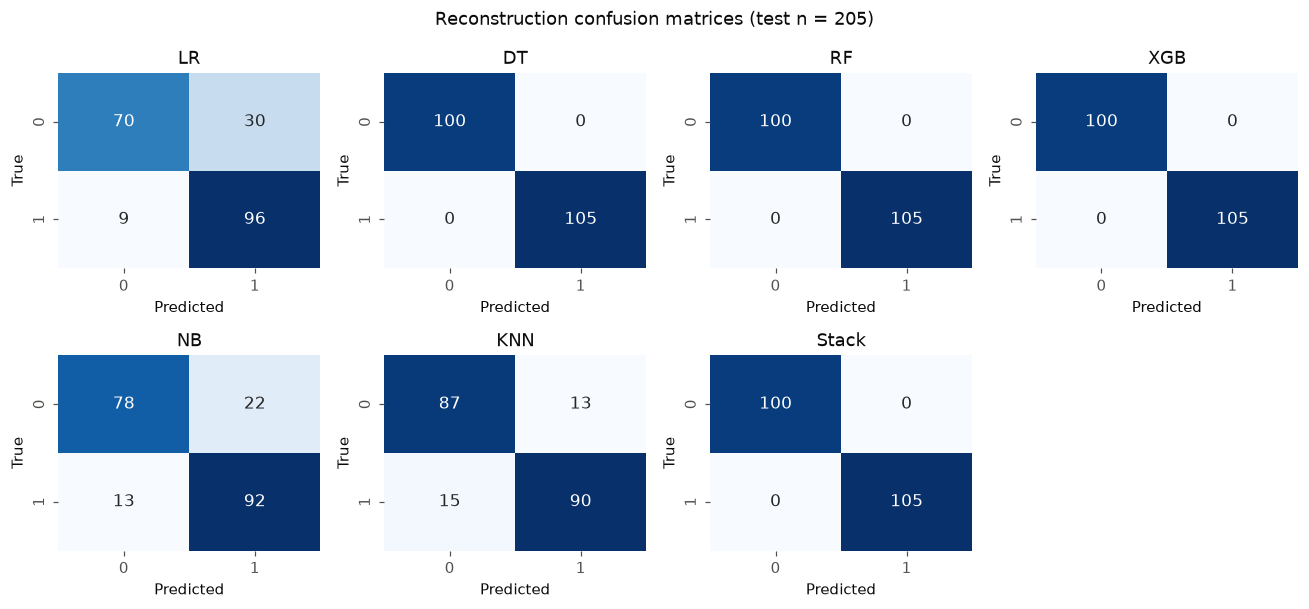

In [8]:
# Figure 1 : paper vs reconstruction across all five metrics
xx = np.arange(len(PART1)); w = 0.38
fig, axes = plt.subplots(1, 5, figsize=(14, 3.7), sharey=True)
for ax, m in zip(axes, METRICS5):
    ax.bar(xx - w/2 - 0.01, [PAPER[k][m] for k in PART1], w, color=C1, label="Paper (Table 11)")
    ax.bar(xx + w/2 + 0.01, [p1[k][m] for k in PART1], w, color=C2, label="My reconstruction")
    ax.set_xticks(xx); ax.set_xticklabels(PART1, rotation=45, ha="right", fontsize=8.5)
    ax.set_ylim(0.6, 1.02); ax.set_title(m, color=INK)
    ax.yaxis.grid(True, color="#e6e5e0", linewidth=0.8); ax.set_axisbelow(True)
axes[0].set_ylabel("Score on the 205-row test set")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=2)
fig.suptitle("Paper-reported vs reconstructed results, all five metrics (1025 rows, 80/20 split)", color=INK)
fig.tight_layout(); fig.savefig("v6_fig1_reproduction.png"); plt.show()

# Figure 2 : reconstruction confusion matrices, including the stack
fig, axes = plt.subplots(2, 4, figsize=(12, 5.6))
for ax, name in zip(axes.ravel(), PART1):
    sns.heatmap(cm1[name], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                annot_kws={"size": 11})
    ax.set_title(name, color=INK); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
axes.ravel()[-1].axis("off")
fig.suptitle("Reconstruction confusion matrices (test n = 205)", color=INK)
fig.tight_layout(); fig.savefig("v6_fig2_cm_part1.png"); plt.show()

# Diagnostics : how duplicates affect the reconstruction
(a) How many of this reconstruction's test rows have an identical copy in its training set?
(b) A group-aware control: identical feature profiles are kept on one side of the split, and the
stack's internal folds are group-disjoint too. This is a diagnostic, not a clean causal estimate:
the split also changes which records are tested and how many.

In [9]:
# (a) overlap audit : same indices as the Part 1 split
itr, ite = train_test_split(np.arange(len(df)), test_size=0.20, random_state=RNG, stratify=y)
assert np.array_equal(df.target.values[ite], yte)
train_profiles = set(map(tuple, df.iloc[itr].values))
overlap = sum(tuple(r) in train_profiles for r in df.iloc[ite].values)
RESULTS["overlap"] = dict(overlap=int(overlap), n=int(len(ite)), pct=round(100 * overlap / len(ite), 2))
print(f"In this reconstruction, {overlap}/{len(ite)} test rows ({100*overlap/len(ite):.2f}%) "
      "have an identical copy in the training set.")

In this reconstruction, 202/205 test rows (98.54%) have an identical copy in the training set.


In [10]:
# (b) group-aware control
gp = df.groupby(FEATURES).ngroup().values
gtr, gte = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RNG).split(X, y, gp))
assert set(gp[gtr]).isdisjoint(gp[gte])
inner_group_folds = list(GroupKFold(n_splits=5).split(X[gtr], y[gtr], gp[gtr]))
for a, b in inner_group_folds:
    assert set(gp[gtr][a]).isdisjoint(gp[gtr][b])
print("Check passed: no identical feature profile crosses the outer split or any internal stacking fold.")

pg = {}
for name, model in base_models():
    mm = pipe(model).fit(X[gtr], y[gtr])
    pg[name] = evaluate(y[gte], mm.predict(X[gte]), mm.predict_proba(X[gte])[:, 1])
sg = paper_stack([(n, pipe(m)) for n, m in base_models()], cv=inner_group_folds).fit(X[gtr], y[gtr])
pg["Stack"] = evaluate(y[gte], sg.predict(X[gte]), sg.predict_proba(X[gte])[:, 1])
RESULTS["groupaware"] = pg
RESULTS["groupaware_split"] = dict(train_rows=int(len(gtr)), test_rows=int(len(gte)),
                                   train_groups=int(len(set(gp[gtr]))), test_groups=int(len(set(gp[gte]))))
print(RESULTS["groupaware_split"])
pd.DataFrame({"Row split": [round(p1[k]["Accuracy"], 4) for k in PART1],
              "Group-aware split": [round(pg[k]["Accuracy"], 4) for k in PART1]}, index=PART1)

Check passed: no identical feature profile crosses the outer split or any internal stacking fold.
{'train_rows': 816, 'test_rows': 209, 'train_groups': 241, 'test_groups': 61}


,Row split,Group-aware split
LR,0.8098,0.7895
DT,1.0000,0.8373
RF,1.0000,0.7703
XGB,1.0000,0.7847
NB,0.8293,0.6938
KNN,0.8634,0.7895
Stack,1.0000,0.7751


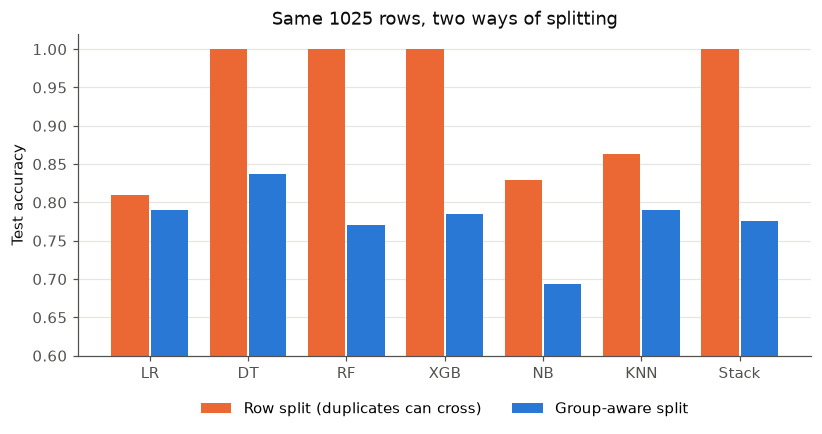

In [11]:
# Figure 3 : row split vs group-aware split
xx = np.arange(len(PART1)); w = 0.38
fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.bar(xx - w/2 - 0.01, [p1[k]["Accuracy"] for k in PART1], w, label="Row split (duplicates can cross)", color=C2)
ax.bar(xx + w/2 + 0.01, [pg[k]["Accuracy"] for k in PART1], w, label="Group-aware split", color=C1)
ax.set_xticks(xx); ax.set_xticklabels(PART1)
ax.set_ylim(0.6, 1.02); ax.set_ylabel("Test accuracy")
ax.yaxis.grid(True, color="#e6e5e0", linewidth=0.8); ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.set_title("Same 1025 rows, two ways of splitting", color=INK)
fig.savefig("v6_fig3_group_diagnostic.png"); plt.show()

# PART 2 : Proposed protocol: deduplicated, nested, leakage-controlled
1. **Deduplicate** to the 302 distinct records, then split into 241 development and 61 holdout
   records (stratified, seed 42).
2. **Preprocess inside the folds**: every model is a `StandardScaler → classifier` pipeline.
3. **Nested cross-validation**: five outer folds (identical for every model). Hyperparameter search
   runs only on each outer training fold, including inside the stack's own internal folds.
4. **Fair tuning ablation**: each search grid contains the untuned default, and the tuned and
   untuned XGBoost both use 100 trees, so the tuned-vs-untuned comparison isolates the search itself.
5. **Estimate validity**: I test each protocol's estimate against the 61 holdout records it never saw.

The holdout was already looked at during earlier project work, so I treat it as a secondary check.

In [12]:
dfu = df.drop_duplicates().reset_index(drop=True)
Xu, yu = dfu[FEATURES].values, dfu["target"].values
Xd, Xh, yd, yh = train_test_split(Xu, yu, test_size=0.20, random_state=RNG, stratify=yu)
RESULTS["split"] = dict(distinct=len(dfu), dev=len(yd), holdout=len(yh))
print(RESULTS["split"])

GRIDS = {
    "RF":  (RandomForestClassifier(n_estimators=100, random_state=RNG),
            {"clf__max_depth": [None, 4], "clf__min_samples_leaf": [1, 4]}),
    "XGB": (XGBClassifier(n_estimators=100, eval_metric="logloss", verbosity=0, random_state=RNG),
            {"clf__max_depth": [6, 3], "clf__learning_rate": [0.3, 0.1]}),
    "KNN": (KNeighborsClassifier(metric="euclidean"),
            {"clf__n_neighbors": [5, 15], "clf__weights": ["uniform", "distance"]})}
RESULTS["grids"] = {k: {p: [str(v) for v in vals] for p, vals in g.items()} for k, (_, g) in GRIDS.items()}
inner = StratifiedKFold(3, shuffle=True, random_state=44)

def untuned_estimators():
    return [(n, pipe(m)) for n, m in base_models()]

def tuned_estimators():
    est = [(n, pipe(m)) for n, m in base_models() if n in ("LR", "DT", "NB")]
    for k, (e, g) in GRIDS.items():
        est.append((k, GridSearchCV(pipe(e), g, cv=inner, scoring="roc_auc", n_jobs=-1)))
    return est

def nested_stack(estimators):
    return StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=1000),
                              cv=StratifiedKFold(5, shuffle=True, random_state=43),
                              stack_method="predict_proba", n_jobs=-1)

{'distinct': 302, 'dev': 241, 'holdout': 61}


In [13]:
outer = StratifiedKFold(5, shuffle=True, random_state=RNG)
NAMES = SINGLES + ["Untuned stack", "Tuned stack"]
pool = {n: (np.zeros(len(yd), dtype=int), np.zeros(len(yd))) for n in NAMES}
fold_id = np.full(len(yd), -1)
perfold = {n: [] for n in NAMES}
selected = []

def fold_metrics(yt, yp, pr):
    return dict(Accuracy=accuracy_score(yt, yp), Precision=precision_score(yt, yp, zero_division=0),
                Recall=recall_score(yt, yp), F1=f1_score(yt, yp), AUC=roc_auc_score(yt, pr))

for fi, (tr, va) in enumerate(outer.split(Xd, yd)):
    fold_id[va] = fi
    fitted = {n: pipe(m).fit(Xd[tr], yd[tr]) for n, m in base_models()}
    fitted["Untuned stack"] = nested_stack(untuned_estimators()).fit(Xd[tr], yd[tr])
    fitted["Tuned stack"] = nested_stack(tuned_estimators()).fit(Xd[tr], yd[tr])
    for k in GRIDS:
        bp = fitted["Tuned stack"].named_estimators_[k].best_params_
        selected.append(dict(fit=f"outer fold {fi + 1}", model=k,
                             params=", ".join(f"{p.replace('clf__', '')}={v}" for p, v in sorted(bp.items()))))
    for n in NAMES:
        yp, pp = fitted[n].predict(Xd[va]), fitted[n].predict_proba(Xd[va])[:, 1]
        pool[n][0][va], pool[n][1][va] = yp, pp
        perfold[n].append(fold_metrics(yd[va], yp, pp))

RESULTS["part2_pooled"] = {n: evaluate(yd, pool[n][0], pool[n][1]) for n in NAMES}
def mean_sd(folds):
    out = {}
    for mname in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
        vals = [f[mname] for f in folds]
        out[mname + "_mean"], out[mname + "_sd"] = float(np.mean(vals)), float(np.std(vals, ddof=1))
    return out
RESULTS["part2_fold_mean_sd"] = {n: mean_sd(perfold[n]) for n in NAMES}

t8 = pd.DataFrame(RESULTS["part2_pooled"]).T[["Accuracy", "Precision", "Recall", "F1", "AUC"]].round(4)
t8["Acc fold mean ± SD"] = [f"{RESULTS['part2_fold_mean_sd'][n]['Accuracy_mean']:.4f} ± {RESULTS['part2_fold_mean_sd'][n]['Accuracy_sd']:.4f}" for n in NAMES]
t8["AUC fold mean ± SD"] = [f"{RESULTS['part2_fold_mean_sd'][n]['AUC_mean']:.4f} ± {RESULTS['part2_fold_mean_sd'][n]['AUC_sd']:.4f}" for n in NAMES]
t8

,Accuracy,Precision,Recall,F1,AUC,Acc fold mean ± SD,AUC fold mean ± SD
LR,0.8382,0.8194,0.9008,0.8582,0.9068,0.8379 ± 0.0963,0.9135 ± 0.0403
DT,0.7759,0.7730,0.8321,0.8015,0.7706,0.7761 ± 0.0704,0.7709 ± 0.0754
RF,0.8506,0.8417,0.8931,0.8667,0.9031,0.8504 ± 0.0433,0.9059 ± 0.0495
XGB,0.7967,0.8106,0.8168,0.8137,0.8882,0.7964 ± 0.0461,0.8891 ± 0.0389
NB,0.8174,0.8129,0.8626,0.8370,0.8920,0.8172 ± 0.0546,0.8950 ± 0.0525
KNN,0.8299,0.8309,0.8626,0.8464,0.8941,0.8298 ± 0.0543,0.9006 ± 0.0295
Untuned stack,0.8050,0.7958,0.8626,0.8278,0.9017,0.8051 ± 0.0556,0.9093 ± 0.0258
Tuned stack,0.8133,0.8028,0.8702,0.8352,0.9047,0.8134 ± 0.0635,0.9117 ± 0.0272


In [14]:
def paired_boot(a, b, reps=2000, seed=7):
    rng = np.random.default_rng(seed); N = len(yd); da, du = [], []
    for _ in range(reps):
        i = rng.integers(0, N, N)
        da.append(accuracy_score(yd[i], pool[a][0][i]) - accuracy_score(yd[i], pool[b][0][i]))
        du.append(roc_auc_score(yd[i], pool[a][1][i]) - roc_auc_score(yd[i], pool[b][1][i]))
    pa = RESULTS["part2_pooled"]
    return dict(comparison=f"{a} − {b}",
                acc_diff_pp=round(100 * (pa[a]["Accuracy"] - pa[b]["Accuracy"]), 2),
                acc_lo=round(100 * np.percentile(da, 2.5), 2), acc_hi=round(100 * np.percentile(da, 97.5), 2),
                auc_diff=round(pa[a]["AUC"] - pa[b]["AUC"], 4),
                auc_lo=round(float(np.percentile(du, 2.5)), 4), auc_hi=round(float(np.percentile(du, 97.5)), 4))

best_single = max(SINGLES, key=lambda n: RESULTS["part2_pooled"][n]["Accuracy"])
pairs = [("Tuned stack", "Untuned stack"), ("Untuned stack", best_single), ("Tuned stack", best_single)]
if best_single != "LR":
    pairs += [("Untuned stack", "LR"), ("Tuned stack", "LR")]
RESULTS["best_single"] = best_single
RESULTS["bootstrap"] = [paired_boot(a, b) for a, b in pairs]
print(f"Best single model by pooled accuracy: {best_single}")
print("Intervals are conditional on these saved predictions; they don't include retraining")
print("variability and don't prove two models are equivalent.")
pd.DataFrame(RESULTS["bootstrap"]).set_index("comparison")

Best single model by pooled accuracy: RF
Intervals are conditional on these saved predictions; they don't include retraining
variability and don't prove two models are equivalent.


,acc_diff_pp,acc_lo,acc_hi,auc_diff,auc_lo,auc_hi
comparison,,,,,,
Tuned stack − Untuned stack,0.83,-0.83,2.49,0.0030,-0.0041,0.0099
Untuned stack − RF,-4.56,-7.88,-1.24,-0.0014,-0.0192,0.0166
Tuned stack − RF,-3.73,-7.05,-0.83,0.0016,-0.0150,0.0184
Untuned stack − LR,-3.32,-7.05,0.00,-0.0051,-0.0242,0.0162
Tuned stack − LR,-2.49,-6.22,0.84,-0.0021,-0.0190,0.0157


In [15]:
final = {n: pipe(m).fit(Xd, yd) for n, m in base_models()}
final["Untuned stack"] = nested_stack(untuned_estimators()).fit(Xd, yd)
final["Tuned stack"] = nested_stack(tuned_estimators()).fit(Xd, yd)
for k in GRIDS:
    bp = final["Tuned stack"].named_estimators_[k].best_params_
    selected.append(dict(fit="final fit (241 records)", model=k,
                         params=", ".join(f"{p.replace('clf__', '')}={v}" for p, v in sorted(bp.items()))))
hold_pred = {n: (final[n].predict(Xh), final[n].predict_proba(Xh)[:, 1]) for n in NAMES}
RESULTS["part2_holdout"] = {n: evaluate(yh, *hold_pred[n]) for n in NAMES}
RESULTS["cm_holdout"] = {n: confusion_matrix(yh, hold_pred[n][0]).tolist() for n in ["Untuned stack", "Tuned stack"]}
sel_df = pd.DataFrame(selected)
RESULTS["selected_hyperparameters"] = sel_df.to_dict(orient="records")
display(sel_df)
pd.DataFrame(RESULTS["part2_holdout"]).T[["Accuracy", "Precision", "Recall", "F1", "AUC"]].round(4)

,fit,model,params
0,outer fold 1,RF,"max_depth=None, min_samples_leaf=4"
1,outer fold 1,XGB,"learning_rate=0.1, max_depth=6"
2,outer fold 1,KNN,"n_neighbors=15, weights=distance"
3,outer fold 2,RF,"max_depth=None, min_samples_leaf=4"
4,outer fold 2,XGB,"learning_rate=0.1, max_depth=3"
5,outer fold 2,KNN,"n_neighbors=15, weights=uniform"
6,outer fold 3,RF,"max_depth=None, min_samples_leaf=4"
7,outer fold 3,XGB,"learning_rate=0.3, max_depth=6"
8,outer fold 3,KNN,"n_neighbors=15, weights=uniform"
9,outer fold 4,RF,"max_depth=None, min_samples_leaf=4"


,Accuracy,Precision,Recall,F1,AUC
LR,0.8033,0.8000,0.8485,0.8235,0.8712
DT,0.7213,0.7500,0.7273,0.7385,0.7208
RF,0.7541,0.7647,0.7879,0.7761,0.8588
XGB,0.7213,0.7353,0.7576,0.7463,0.8323
NB,0.7869,0.8333,0.7576,0.7937,0.8842
KNN,0.7869,0.7778,0.8485,0.8116,0.8377
Untuned stack,0.7541,0.7647,0.7879,0.7761,0.8755
Tuned stack,0.7541,0.7647,0.7879,0.7761,0.8864


## Estimate validity: which protocol tells the truth about unseen records?
Both protocols are trained only on the 241 development records (the paper's protocol also gets all
their duplicate rows, i.e. every row of the 1025-row file that isn't a copy of a holdout record).
Each protocol produces its own accuracy **estimate**. I then score the same trained models on the 61
holdout records neither protocol has seen and compare. Wilson 95% intervals show how noisy a
61-record accuracy is.

In [16]:
def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d; h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h

hold_profiles = set(map(tuple, Xh))
mask = np.array([tuple(r) not in hold_profiles for r in X])
Xl, yl = X[mask], y[mask]
assert set(map(tuple, Xl)) == set(map(tuple, Xd)), "development rows must be exactly the 241 dev records"
Xl_tr_raw, Xl_te_raw, yl_tr, yl_te = train_test_split(Xl, yl, test_size=0.20, random_state=RNG, stratify=yl)
scl = StandardScaler().fit(Xl_tr_raw)
leaky_models = base_models() + [("Stack", paper_stack(base_models(), cv=5))]
rows = []
paper_dev_metrics = {}
for name, model in leaky_models:
    model.fit(scl.transform(Xl_tr_raw), yl_tr)
    pe, pre = model.predict(scl.transform(Xl_te_raw)), model.predict_proba(scl.transform(Xl_te_raw))[:, 1]
    ph, prh = model.predict(scl.transform(Xh)), model.predict_proba(scl.transform(Xh))[:, 1]
    paper_dev_metrics[name] = dict(estimate=evaluate(yl_te, pe, pre), unseen=evaluate(yh, ph, prh))
    est = accuracy_score(yl_te, pe)
    k = int((ph == yh).sum())
    lo, hi = wilson(k, len(yh))
    rows.append(dict(protocol="Paper protocol", model=name, estimate=est, realised=k / len(yh),
                     realised_lo=lo, realised_hi=hi))

for name in SINGLES + ["Untuned stack", "Tuned stack"]:
    k = int((hold_pred[name][0] == yh).sum())
    lo, hi = wilson(k, len(yh))
    rows.append(dict(protocol="Nested protocol", model=("Stack" if name == "Untuned stack" else name),
                     estimate=RESULTS["part2_pooled"][name]["Accuracy"], realised=k / len(yh),
                     realised_lo=lo, realised_hi=hi))
ev = pd.DataFrame(rows)
ev["gap_pp"] = 100 * (ev.estimate - ev.realised)
ev["estimate_outside_CI"] = (ev.estimate < ev.realised_lo) | (ev.estimate > ev.realised_hi)
RESULTS["leaky_dev_rows"] = int(mask.sum())
RESULTS["paper_protocol_dev_metrics"] = paper_dev_metrics
RESULTS["estimate_validity"] = ev.to_dict(orient="records")

shared = SINGLES + ["Stack"]  
summary = {}
for proto in ["Paper protocol", "Nested protocol"]:
    s = ev[(ev.protocol == proto) & ev.model.isin(shared)]
    summary[proto] = dict(mean_abs_gap_pp=round(float(s.gap_pp.abs().mean()), 2),
                          max_gap_pp=round(float(s.gap_pp.max()), 2),
                          outside_CI=int(s.estimate_outside_CI.sum()), n_models=int(len(s)))
RESULTS["estimate_validity_summary"] = summary
print(f"Paper-protocol development rows: {mask.sum()}")
print(summary)
ev.round(4)

Paper-protocol development rows: 819
{'Paper protocol': {'mean_abs_gap_pp': 20.28, 'max_gap_pp': 31.15, 'outside_CI': 6, 'n_models': 7}, 'Nested protocol': {'mean_abs_gap_pp': 5.51, 'max_gap_pp': 9.65, 'outside_CI': 1, 'n_models': 7}}


,protocol,model,estimate,realised,realised_lo,realised_hi,gap_pp,estimate_outside_CI
0,Paper protocol,LR,0.8720,0.7869,0.6688,0.8710,8.5066,True
1,Paper protocol,DT,1.0000,0.6885,0.5641,0.7906,31.1475,True
2,Paper protocol,RF,0.9817,0.7377,0.6156,0.8316,24.4002,True
3,Paper protocol,XGB,1.0000,0.7049,0.5811,0.8045,29.5082,True
4,Paper protocol,NB,0.8049,0.7869,0.6688,0.8710,1.7993,False
5,Paper protocol,KNN,0.9085,0.7213,0.5983,0.8181,18.7225,True
6,Paper protocol,Stack,1.0000,0.7213,0.5983,0.8181,27.8689,True
7,Nested protocol,LR,0.8382,0.8033,0.6869,0.8837,3.4896,False
8,Nested protocol,DT,0.7759,0.7213,0.5983,0.8181,5.4622,False
9,Nested protocol,RF,0.8506,0.7541,0.6332,0.8449,9.6524,True


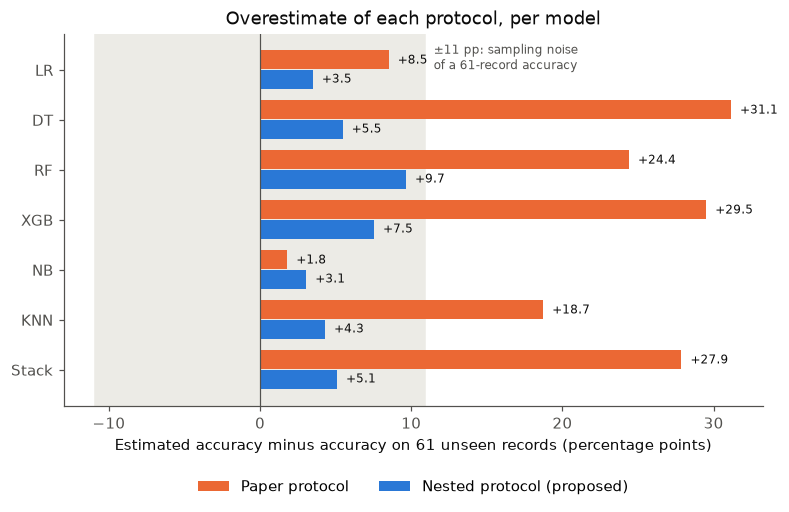

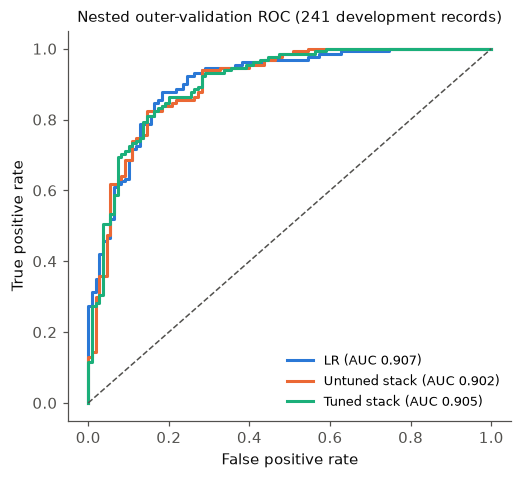

In [17]:
# Figure 4 : how far each protocol's estimate overshoots the unseen-record accuracy
g = ev[ev.model.isin(shared)].pivot(index="model", columns="protocol", values="gap_pp").loc[shared[::-1]]
yy = np.arange(len(g)); h = 0.38
p_bar = float(ev.realised.mean())
se_band = 100 * 1.96 * np.sqrt(p_bar * (1 - p_bar) / len(yh))
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.axvspan(-se_band, se_band, color="#ecebe6", zorder=0)
ax.text(se_band + 0.6, len(g) - 0.45, f"±{se_band:.0f} pp: sampling noise\nof a 61-record accuracy", color=MUTED, fontsize=8, va="top")
ax.barh(yy + h/2 + 0.01, g["Paper protocol"], h, color=C2, label="Paper protocol")
ax.barh(yy - h/2 - 0.01, g["Nested protocol"], h, color=C1, label="Nested protocol (proposed)")
for i, (a, b) in enumerate(zip(g["Paper protocol"], g["Nested protocol"])):
    ax.text(a + (0.6 if a >= 0 else -0.6), i + h/2, f"{a:+.1f}", va="center", ha="left" if a >= 0 else "right", fontsize=8, color=INK)
    ax.text(b + (0.6 if b >= 0 else -0.6), i - h/2, f"{b:+.1f}", va="center", ha="left" if b >= 0 else "right", fontsize=8, color=INK)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_yticks(yy); ax.set_yticklabels(g.index)
ax.set_xlabel("Estimated accuracy minus accuracy on 61 unseen records (percentage points)")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
ax.set_title("Overestimate of each protocol, per model", color=INK)
fig.savefig("v6_fig4_estimate_validity.png"); plt.show()

# Figure 5 : outer-validation ROC on the development records
fig, ax = plt.subplots(figsize=(5.2, 4.6))
for name, col in [("LR", C1), ("Untuned stack", C2), ("Tuned stack", C3)]:
    fpr, tpr, _ = roc_curve(yd, pool[name][1])
    ax.plot(fpr, tpr, color=col, linewidth=2, label=f"{name} (AUC {RESULTS['part2_pooled'][name]['AUC']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color=MUTED, linewidth=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
ax.set_title("Nested outer-validation ROC (241 development records)", color=INK, fontsize=10)
fig.savefig("v6_fig5_roc_dev.png"); plt.show()

## Comparison with the paper across all five metrics
How far do my reconstruction (Part 1 baseline) and my proposed nested protocol sit from the paper's
Table 11, metric by metric? For the nested protocol the stack row uses the untuned stack, which has
the same settings as the paper's model.

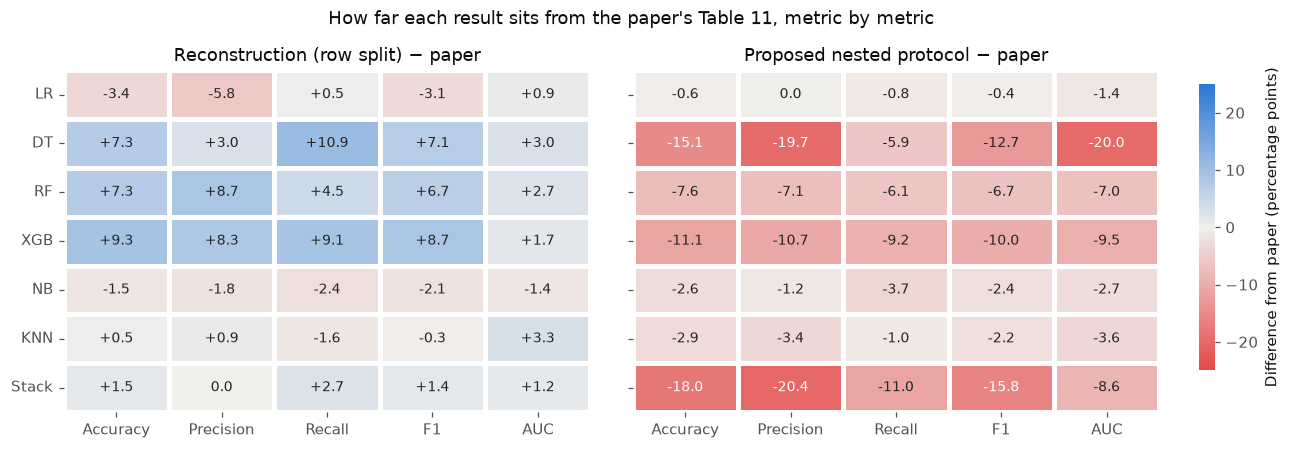

{'reconstruction_mean_diff_pp': 2.51, 'nested_mean_diff_pp': -7.46, 'nested_cells_below_paper': 35, 'cells': 35}


,Accuracy,Precision,Recall,F1,AUC
setting,,,,,
Paper (Table 11),0.9853,1.0000,0.9727,0.9861,0.9880
"Reconstruction, row split (Part 1 baseline)",1.0000,1.0000,1.0000,1.0000,1.0000
Group-aware split of the same 1025 rows,0.7751,0.7623,0.8378,0.7983,0.8538
Paper protocol on development rows: own estimate,1.0000,1.0000,1.0000,1.0000,1.0000
same model on 61 unseen records,0.7213,0.7500,0.7273,0.7385,0.8409
"Nested protocol, untuned stack: pooled estimate",0.8050,0.7958,0.8626,0.8278,0.9017
same model on 61 unseen records,0.7541,0.7647,0.7879,0.7761,0.8755
"Nested protocol, tuned stack: pooled estimate",0.8133,0.8028,0.8702,0.8352,0.9047
same model on 61 unseen records,0.7541,0.7647,0.7879,0.7761,0.8864


In [18]:
from matplotlib.colors import LinearSegmentedColormap
nest_name = lambda k: "Untuned stack" if k == "Stack" else k
rec = pd.DataFrame({m: [100 * (p1[k][m] - PAPER[k][m]) for k in PART1] for m in METRICS5}, index=PART1)
nes = pd.DataFrame({m: [100 * (RESULTS["part2_pooled"][nest_name(k)][m] - PAPER[k][m]) for k in PART1]
                    for m in METRICS5}, index=PART1)
RESULTS["paper_vs_nested"] = {k: {m: dict(paper=PAPER[k][m], nested=RESULTS["part2_pooled"][nest_name(k)][m],
                                          diff_pp=float(nes.loc[k, m])) for m in METRICS5} for k in PART1}
RESULTS["paper_diff_summary"] = dict(
    reconstruction_mean_diff_pp=round(float(rec.values.mean()), 2),
    nested_mean_diff_pp=round(float(nes.values.mean()), 2),
    nested_cells_below_paper=int((nes.values < 0).sum()), cells=int(nes.size))

# Figure 6 : difference from the paper (diverging: red = below paper, blue = above, grey = equal)
div = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
lim = float(np.ceil(max(rec.abs().values.max(), nes.abs().values.max()) / 5) * 5)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
cbar_ax = fig.add_axes([0.93, 0.2, 0.012, 0.62])
for i, (ax, d, title) in enumerate([(axes[0], rec, "Reconstruction (row split) − paper"),
                                    (axes[1], nes, "Proposed nested protocol − paper")]):
    labels = d.map(lambda v: "0.0" if abs(v) < 0.05 else f"{v:+.1f}")
    sns.heatmap(d, annot=labels, fmt="", cmap=div, vmin=-lim, vmax=lim, center=0, ax=ax,
                linewidths=2, linecolor="white", annot_kws={"size": 9},
                cbar=(i == 1), cbar_ax=cbar_ax if i == 1 else None,
                cbar_kws={"label": "Difference from paper (percentage points)"})
    ax.set_title(title, color=INK); ax.tick_params(axis="y", rotation=0)
fig.suptitle("How far each result sits from the paper's Table 11, metric by metric", color=INK)
fig.subplots_adjust(left=0.07, right=0.9, top=0.85, wspace=0.08)
fig.savefig("v6_fig6_paper_comparison.png"); plt.show()
print(RESULTS["paper_diff_summary"])

settings = [
    ("Paper (Table 11)", PAPER["Stack"]),
    ("Reconstruction, row split (Part 1 baseline)", p1["Stack"]),
    ("Group-aware split of the same 1025 rows", pg["Stack"]),
    ("Paper protocol on development rows: own estimate", paper_dev_metrics["Stack"]["estimate"]),
    ("  same model on 61 unseen records", paper_dev_metrics["Stack"]["unseen"]),
    ("Nested protocol, untuned stack: pooled estimate", RESULTS["part2_pooled"]["Untuned stack"]),
    ("  same model on 61 unseen records", RESULTS["part2_holdout"]["Untuned stack"]),
    ("Nested protocol, tuned stack: pooled estimate", RESULTS["part2_pooled"]["Tuned stack"]),
    ("  same model on 61 unseen records", RESULTS["part2_holdout"]["Tuned stack"])]
stack_tbl = pd.DataFrame([{"setting": name, **{m: float(v[m]) for m in METRICS5}} for name, v in settings])
RESULTS["stack_across_settings"] = stack_tbl.to_dict(orient="records")
stack_tbl.set_index("setting").round(4)

## 3. Export everything the report uses

In [19]:
oof = pd.DataFrame({"dev_index": np.arange(len(yd)), "y_true": yd, "outer_fold": fold_id})
for n in NAMES:
    oof[f"{n}_pred"], oof[f"{n}_proba"] = pool[n][0], pool[n][1]
oof.to_csv("oof_predictions.csv", index=False)

hold = pd.DataFrame({"holdout_index": np.arange(len(yh)), "y_true": yh})
for n in NAMES:
    hold[f"{n}_pred"], hold[f"{n}_proba"] = hold_pred[n]
hold.to_csv("holdout_predictions.csv", index=False)

pd.DataFrame([{"model": n, "fold": i, **{k: round(v, 4) for k, v in f.items()}}
              for n in NAMES for i, f in enumerate(perfold[n])]).to_csv("perfold_metrics.csv", index=False)
sel_df.to_csv("selected_hyperparameters.csv", index=False)
ev.to_csv("estimate_validity.csv", index=False)
pd.DataFrame(RESULTS["bootstrap"]).to_csv("bootstrap_comparisons.csv", index=False)
pd.concat({"reconstruction_minus_paper_pp": rec, "nested_minus_paper_pp": nes}).to_csv("paper_comparison_all_metrics.csv")
stack_tbl.to_csv("stack_across_settings.csv", index=False)

env = {"python": platform.python_version(), "platform": platform.platform()}
for p in ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "xgboost"]:
    env[p] = ilm.version(p)
json.dump(env, open("environment.json", "w"), indent=2)
RESULTS["environment"] = env
json.dump(RESULTS, open("results_v6.json", "w"), indent=2, default=float)
print("Exported results_v6.json, environment.json, 8 CSV files and v6_fig1–6.png")
print(env)

Exported results_v6.json, environment.json, 8 CSV files and v6_fig1–6.png
{'python': '3.11.15', 'platform': 'macOS-26.6.2-arm64-arm-64bit', 'scikit-learn': '1.9.0', 'pandas': '3.0.5', 'numpy': '2.4.6', 'matplotlib': '3.11.1', 'seaborn': '0.13.2', 'xgboost': '3.2.0'}


## 4. Summary
* The reconstruction reproduces the paper's pattern, but almost every test row has an identical copy in the training set, so those scores say little about unseen records.
* Under the proposed nested protocol on distinct records, accuracy is about 0.80–0.85, the stack doesn't beat the best single model (random forest), and tuning doesn't clearly help. Across all five metrics, the nested results sit below the paper's Table 11.
* The key test: the paper's protocol overestimates accuracy on unseen records by a wide margin, while the nested protocol's estimate lands close to what actually happens. That is the improvement.